# Model Evaluation

In [8]:
import sys, os
sys.path.append(os.path.abspath("../src"))

import torch
import torch.nn as nn
import numpy as np
import gc
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
from midas.models.models import DetectionModel
from midas.data.build_datasets import val_loader, test_loader, PAD_loader, dark_skin_loader, light_skin_loader, random_skin_loader 
from midas.data.augmentation import standard_transform
from sklearn.metrics import (roc_auc_score, recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve)
from captum.concept import TCAV, Concept

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DetectionModel().to(device)

best_state = torch.load("../../deep-learning-project/src/midas/training/best_model.pth", weights_only=True)

### Traditional Model Evaluation

In [12]:
def get_predictions(model, loader):

    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, _, _, label in loader:

            images = images.squeeze(0).to(device)
            label = label.float().to(device)

            logits = model(images)
            probs = torch.sigmoid(logits)

            all_probs.append(probs.view(-1).cpu())
            all_labels.append(label.view(-1).cpu())

    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return all_probs, all_labels
    
def evaluate_model(model, loader, name="Dataset", threshold=0.1):

    probs, labels = get_predictions(model, loader)

    print(f"\n{name}")
    print("AUC:", roc_auc_score(labels, probs))
    print("Prediction range:", probs.min(), "-", probs.max())

    preds = (probs >= threshold).astype(int)

    recall = recall_score(labels, preds)
    precision = precision_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)

    print(f"Threshold: {threshold:.3f}")
    print("Recall:", recall)
    print("Precision:", precision)
    print("F1:", f1)

    fpr, tpr, _ = roc_curve(labels, probs)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.show()

    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

Best threshold: 0.130 (F1: 0.4545)

Test
AUC: 0.5861833105335157
Prediction range: 0.06341565 - 0.2905805
Threshold: 0.130
Recall: 0.9411764705882353
Precision: 0.19753086419753085
F1: 0.326530612244898


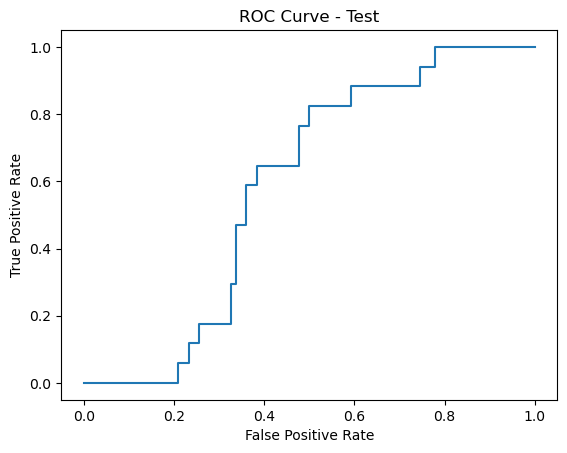

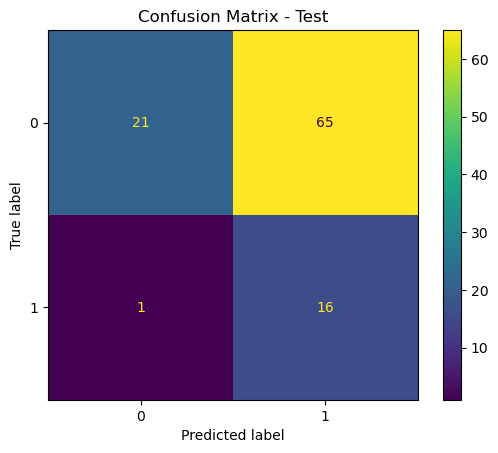


PAD
AUC: 0.46548061603823687
Prediction range: 0.072140604 - 0.45588213
Threshold: 0.130
Recall: 0.8928571428571429
Precision: 0.019425019425019424
F1: 0.03802281368821293


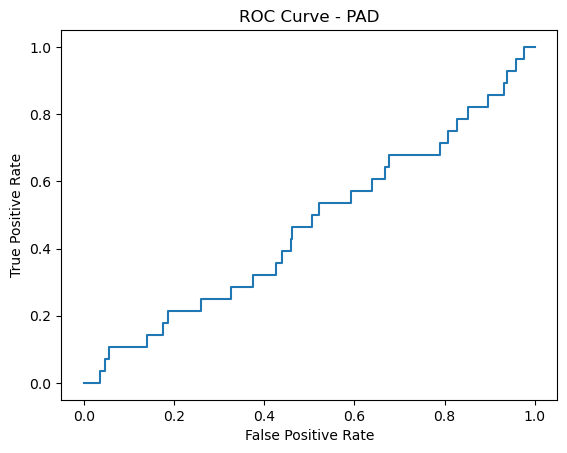

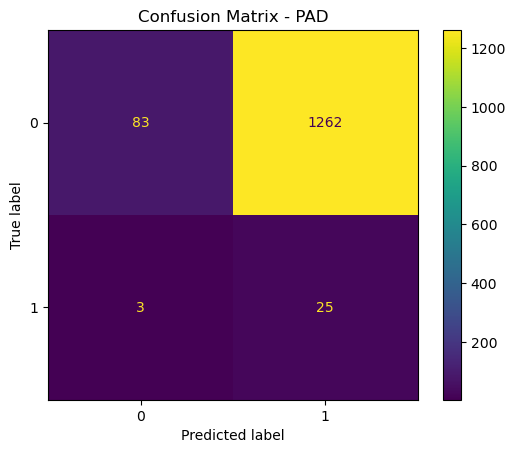

In [13]:
model.load_state_dict(best_state)

all_probs, all_labels = get_predictions(model, val_loader)

best_thresh = 0.15
best_f1 = 0

for thresh in np.arange(0.05, 0.95, 0.01):
    preds = (all_probs >= thresh).astype(int)
    recall = recall_score(all_labels, preds, zero_division=0)
    precision = precision_score(all_labels, preds, zero_division=0)
    f1 = f1_score(all_labels, preds, zero_division=0)

    if recall >= 0.6 and f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"Best threshold: {best_thresh:.3f} (F1: {best_f1:.4f})")

evaluate_model(model, test_loader, "Test", threshold=best_thresh)
evaluate_model(model, PAD_loader, "PAD", threshold=best_thresh)

### TCAV Model Evaluation

In [7]:
shutil.rmtree("/tmp/tcav_results/", ignore_errors=True)

device = torch.device("cpu")
model.to(device)
model.eval()

class ModelWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        logits = self.model(x)

        if logits.dim() == 0:
            logits = logits.unsqueeze(0).unsqueeze(1)
        elif logits.dim() == 1:
            logits = logits.unsqueeze(1)

        return torch.cat([-logits, logits], dim=1)

wrapped_model = ModelWrapper(model)

def limit_loader(loader, max_batches=5): # reducing loader size, kernal kept resarting
    for i, batch in enumerate(loader):
        if i >= max_batches:
            break
        yield batch

dark_iter = limit_loader(dark_skin_loader, max_batches=5)
light_iter = limit_loader(light_skin_loader, max_batches=5)
random_iter = limit_loader(random_skin_loader, max_batches=5)

dark_concept = Concept(id=0, name="dark", data_iter=dark_iter)
light_concept = Concept(id=1, name="light", data_iter=light_iter)
random_concept = Concept(id=2, name="random", data_iter=random_iter)

input_imgs = []

for i, (images, _, _, _) in enumerate(PAD_loader):
    if i >= 16:
        break
    img = images.squeeze(0)
    if img.ndim == 4:
        img = img[0]
    input_imgs.append(img)

input_tensor = torch.stack(input_imgs).to(device)

gc.collect()
torch.cuda.empty_cache()

tcav = TCAV(model=wrapped_model, layers=["model.encoder.4"], model_id="safe_tcav", save_path="/tmp/tcav_results/")
dark_scores = tcav.interpret(inputs=input_tensor, experimental_sets=[[dark_concept, random_concept]], target=1)
gc.collect()
light_scores = tcav.interpret(inputs=input_tensor, experimental_sets=[[light_concept, random_concept]], target=1)

def print_scores(scores, title):
    print(f"\n{title}")
    for layer, layer_scores in scores.items():
        vals = list(layer_scores.values())

        if not vals:
            print(f"{layer}: no scores")
            continue

        metric = vals[0]

        magnitude = metric['magnitude'][0].item()
        sign = metric['sign_count'][0].item()

        print(f"{layer}: magnitude={magnitude:.4f}, sign={sign:.4f}")

print_scores(dark_scores, "Dark Skin TCAV")
print_scores(light_scores, "Light Skin TCAV")

/home/ogleason/.local/lib/python3.8/site-packages/captum/concept/_utils/classifier.py:130: UserWarning: Using default classifier for TCAV which keeps input both train and test datasets in the memory. Consider defining your own classifier that doesn't rely heavily on memory, for large number of concepts, by extending `Classifer` abstract class
  warnings.warn(
/home/ogleason/.local/lib/python3.8/site-packages/captum/_utils/av.py:80: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this


Dark Skin TCAV
0-2: magnitude=-0.0073, sign=0.0000

Light Skin TCAV
1-2: magnitude=0.0041, sign=1.0000
